# Music, Brain & Wellbeing: Decision Tree Regression

This notebook trains, evaluates, and interprets an untuned **Decision Tree Regressor** on the MXMH dataset. We compare its performance against the Linear Regression baseline to study overfitting and non-linear feature split logic.

We follow a first-principles approach:
1. Explain the Decision Tree concept.
2. Build the model pipeline using our custom preprocessing.
3. Train strictly on the training set and evaluate on both train and test sets.
4. Diagnose overfitting by comparing training and test performance.
5. Extract model feature importances.
6. Answer quantitative technical interview questions.



## 1. The Decision Tree Concept

### WHAT:
A Decision Tree predicts a target value by repeatedly splitting observations into smaller subgroups according to feature conditions.

### WHY:
Unlike Linear Regression, which assumes a strictly additive linear relationship, a Decision Tree can model non-linear boundaries and feature interactions without requiring mathematical functions (like polynomial transformations).

### Simple Mental Model:

```
                  feature condition
                        ↓ (Yes / No)
                      split
                        ↓
                   another condition
                        ↓ (Yes / No)
                      split
                        ↓
                     prediction
```



## 2. Load Data and Split

We load `data/processed/mxmh_cleaned.csv`, split into features (X) and target (y), and apply an 80/20 train/test split.



In [1]:
import pandas as pd
import numpy as np
import sys
import os

# Add parent directory to sys.path to allow importing src
sys.path.append(os.path.abspath(".."))

from src.features.preprocessing import build_preprocessor

# Load preprocessed dataset
df = pd.read_csv("../data/processed/mxmh_cleaned.csv")

# Target variable y
y = df["Anxiety"]

# Feature space X
X = df.drop(columns=["Anxiety", "Depression", "Insomnia", "OCD"])

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (736, 27)
y shape: (736,)


In [2]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])



Training size: 588
Testing size: 148


## 3. Build the Decision Tree Pipeline

We construct a scikit-learn `Pipeline` that chains our ColumnTransformer preprocessor and the `DecisionTreeRegressor` estimator. 
We start with a default, untuned tree (`random_state=42`) to observe its natural behavior.



In [3]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Classify columns based on data type
categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)
numerical_cols = list(X.select_dtypes(include=["int64", "float64"]).columns)

# Construct preprocessor ColumnTransformer
preprocessor = build_preprocessor(numerical_cols, categorical_cols)

# Wrap preprocessing and DecisionTreeRegressor in a Pipeline
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

print("Pipeline constructed successfully.")



Pipeline constructed successfully.


C:\Users\aksha\AppData\Local\Temp\ipykernel_31568\459904025.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)


## 4. Train the Model

We train the pipeline strictly on the training set (`X_train`, `y_train`).



In [4]:
# Train model pipeline
dt_pipeline.fit(X_train, y_train)
print("Decision Tree pipeline trained successfully.")



Decision Tree pipeline trained successfully.


## 5. Make Predictions

We generate predictions for both our training set (to check for training fit) and our test set (to check for generalization).



In [5]:
# Generate predictions
y_pred_train = dt_pipeline.predict(X_train)
y_pred_test = dt_pipeline.predict(X_test)

print("First 5 training predictions:", y_pred_train[:5])
print("First 5 testing predictions :", y_pred_test[:5])



First 5 training predictions: [ 8.  6. 10.  3.  6.]
First 5 testing predictions : [5. 4. 5. 4. 7.]


## 6. Evaluation

We calculate MAE, RMSE, and R² for both training and testing predictions.



In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(y_true, y_pred, subset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {subset_name} Metrics ===")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  R²    : {r2:.4f}")
    return mae, rmse, r2

mae_dt_train, rmse_dt_train, r2_dt_train = compute_metrics(y_train, y_pred_train, "Decision Tree (Train)")
print()
mae_dt_test, rmse_dt_test, r2_dt_test = compute_metrics(y_test, y_pred_test, "Decision Tree (Test)")



=== Decision Tree (Train) Metrics ===
  MAE   : 0.0000
  RMSE  : 0.0000
  R²    : 1.0000

=== Decision Tree (Test) Metrics ===
  MAE   : 3.3480
  RMSE  : 4.1258
  R²    : -1.1078


## 7. Model Comparison Table

Below we construct a comparison table using our actual Linear Regression and Decision Tree results.



In [7]:
# Linear Regression performance metrics (from baseline model)
# Train: MAE=2.1321, RMSE=2.5961, R2=0.1267
# Test : MAE=2.4173, RMSE=2.8786, R2=-0.0261

comparison_data = {
    "Model": ["Linear Regression", "Decision Tree"],
    "Train MAE": [2.1321, mae_dt_train],
    "Test MAE": [2.4173, mae_dt_test],
    "Train RMSE": [2.5961, rmse_dt_train],
    "Test RMSE": [2.8786, rmse_dt_test],
    "Train R²": [0.1267, r2_dt_train],
    "Test R²": [-0.0261, r2_dt_test]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4).to_string(index=False))



            Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
Linear Regression     2.1321    2.4173      2.5961     2.8786    0.1267  -0.0261
    Decision Tree     0.0000    3.3480      0.0000     4.1258    1.0000  -1.1078


## 8. Understanding Overfitting

### Diagnosing the Split
Looking at the comparison table above:
- **Decision Tree Train R²**: **`1.0000`** (Perfect prediction; 0 error)
- **Decision Tree Test R²**: **`-1.1078`** (Severe prediction failure; worse than predicting the mean)

### What is happening?
An untuned Decision Tree has no depth limit. During fitting, it will split nodes until every leaf is completely pure (usually containing exactly one training observation). This allows it to memorize the training data perfectly. 

However, because the rules are so specific to individual training samples, they fail to generalize to unseen test observations. The tree has captured noise rather than signal. This is a classic case of **overfitting**.



## 9. Feature Importance (Predictive Importance)

We extract the relative importance assigned to each feature by the Decision Tree.

* **Caution**: Feature importance represents the relative reduction in squared error (variance) contributed by each feature's splits. It is a measure of **predictive importance** for this model. It does **not** prove a causal link between the feature and anxiety, and carries no clinical significance.



In [8]:
# Extract feature importances
dt_model = dt_pipeline.named_steps["regressor"]

# Get one-hot feature names
ohe_feature_names = dt_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(ohe_feature_names)

# Create DataFrame
importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": dt_model.feature_importances_
})

# Sort by importance descending
sorted_importances = importances.sort_values(by="Importance", ascending=False)

print("Top 10 Most Important Features in Decision Tree:")
print(sorted_importances.head(10).to_string(index=False))



Top 10 Most Important Features in Decision Tree:
                     Feature  Importance
                         Age    0.126538
                         BPM    0.093341
               Hours per day    0.067022
             Frequency [Rap]    0.049124
             Frequency [Pop]    0.047934
         Frequency [Hip hop]    0.042470
             Frequency [EDM]    0.039102
         Frequency [Country]    0.037106
Frequency [Video game music]    0.036686
           Frequency [Metal]    0.036414


## 10. Visualizations

We generate two simple, clean plots to compare performance and display feature importances.



C:\Users\aksha\AppData\Local\Temp\ipykernel_31568\1429784301.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=test_rmse_vals, palette="coolwarm")


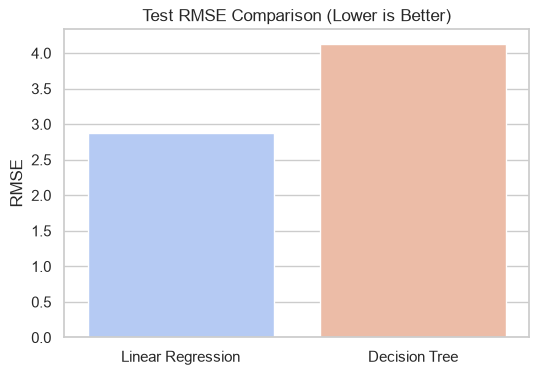

C:\Users\aksha\AppData\Local\Temp\ipykernel_31568\1429784301.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_10, palette="viridis")


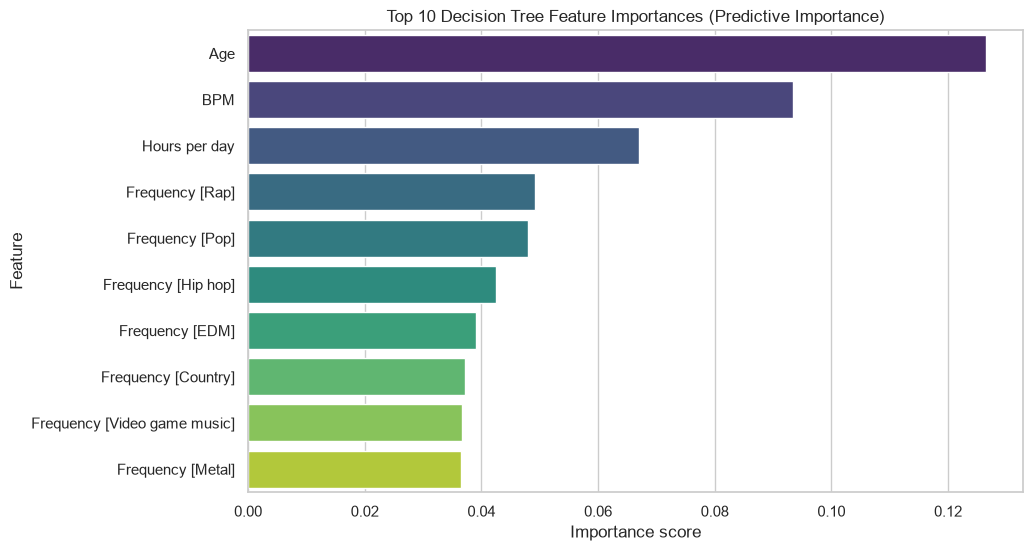

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot 1: Test RMSE Comparison
plt.figure(figsize=(6, 4))
models = ["Linear Regression", "Decision Tree"]
test_rmse_vals = [2.8786, rmse_dt_test]
sns.barplot(x=models, y=test_rmse_vals, palette="coolwarm")
plt.title("Test RMSE Comparison (Lower is Better)")
plt.ylabel("RMSE")
plt.savefig("../docs/figures/lr_vs_dt_test_rmse.png", bbox_inches="tight")
plt.show()

# Plot 2: Decision Tree Top 10 Feature Importances
plt.figure(figsize=(10, 6))
top_10 = sorted_importances.head(10)
sns.barplot(x="Importance", y="Feature", data=top_10, palette="viridis")
plt.title("Top 10 Decision Tree Feature Importances (Predictive Importance)")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.savefig("../docs/figures/dt_feature_importance.png", bbox_inches="tight")
plt.show()



## 11. Interpretation

### 1. Did the Decision Tree outperform Linear Regression?
No, on the test set it performed significantly worse. The test RMSE increased from 2.8786 to 4.1258, and the R² dropped from -0.0261 to -1.1078.

### 2. Is there evidence of overfitting?
Yes. The Train R² is 1.0000, while the Test R² is -1.1078. This indicates the model memorized the training set but failed completely on the test set.

### 3. Which features were most important to the tree?
`Age` (~12.7%), `BPM` (~9.3%), and `Hours per day` (~6.7%) were the most important features. 

### 4. What does this tell us about the structure of our dataset?
Since the primary split features are continuous (Age, BPM, Hours per day), the tree has partitioned them into highly specific intervals to isolate training samples. Because the signal-to-noise ratio is low, this leads to overfitting. We need to introduce regularizing constraints (like `max_depth`, `min_samples_split`) or use ensemble methods (Random Forests) in the next stage.



---
## Technical Interview Questions

### 1. Why did we use Linear Regression as a baseline?
Linear Regression is transparent, simple, and has no capacity to overfit complex interactions. It serves as a benchmark to ensure that more complex models (like Decision Trees) add real predictive value.

### 2. Why did we try a Decision Tree?
To see if capturing non-linear relationships or thresholds (e.g., listening hours > 5 hours, or specific age groups) would yield better performance than a simple linear model.

### 3. How does a Decision Tree perform regression?
It splits the data into regions. For any test observation, it traverses the tree based on the feature rules until it reaches a leaf node. The prediction is the mean target value of all training observations mapped to that leaf node.

### 4. What is a tree split?
A partition of the dataset at a node into two subsets based on a feature value threshold. The split is chosen by finding the threshold that minimizes the split criterion (e.g. Mean Squared Error) across the resulting subsets.

### 5. What is overfitting?
When a model learns the random noise and details of the training set rather than the underlying general relationships, resulting in high training performance but poor performance on unseen test data.

### 6. How can train/test performance reveal overfitting?
A huge gap between train performance (e.g. R² = 1.0) and test performance (e.g. R² = -1.1) is a clear symptom of overfitting, indicating the model memorized training samples but failed to generalize.

### 7. What is feature importance?
A metric representing the total reduction in split criterion (variance/MSE) contributed by each feature. It indicates how much the model relied on a feature to make splits.

### 8. Does feature importance imply causation?
No. Feature importance measures association within the model's structure. It does not establish a physical cause-and-effect relationship between the feature and the target.

### 9. Why is it important to compare models using the same test set?
Using the exact same test set ensures a fair, controlled comparison. If different test sets were used, variance in the test distributions could make one model look artificially better or worse.

